# World Happiness Report Kaggle Dataset Analysis
[Original dataset]('https://www.kaggle.com/datasets/unsdsn/world-happiness')

## Opening Questions

### Context
1. What is the source of the data? 
This dataset is published on Kaggle with a license for use in the public domain.

2. Who collected it, how, and when? 
The United Nations releases the report on World Happiness day, March 20th, using data collected from the Gallup World Poll.
3. What are the known biases and limitations? 
The design of the dataset includes a fictional country, Dystopia, which represents the unhappiest country in the world. The measure against Dystopia guarantees that all countries score favorably in comparison. 

### Sampling
1. Is the dataset representative of the population of interest? 
3. Are there subgroups that need separate analysis?

### Structure
1. What are the dimensions? 
782 rows, 15 columns
2. Are there missing values, and how are they represented?
There are missing values across columns that do not appear from one year to the next. 

### Quality
1. Are there duplicates? 
No duplicates detected
2. Inconsistent values? 

3. Columns that look numeric but contain strings? 
Across source files column names did vary, so I handled this in the `aggregate_yearly_reports` util when combining all source files into one. 
4. Outliers visible even before any statistics are computed?

In [1]:
from utils import aggregate_yearly_reports, min_max_normalization
import pandas as pd

## Create a single dataframe after normalizing headers across all files
## Add synthetic field survey_year that is derived from the source file name, assuming the pattern <YEAR>.csv
aggregated_csv = aggregate_yearly_reports(['./data/2015.csv', './data/2016.csv', './data/2017.csv', './data/2018.csv', './data/2019.csv'])

df = pd.read_csv(aggregated_csv)

df.head()

,country,region,happiness_rank,happiness_score,standard_error,gdp_per_capita,social_support,healthy_life_expectancy,freedom,perceptions_of_corruption,generosity,dystopia_residual,survey_year,lower_confidence_interval,upper_confidence_interval
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015,NaN,NaN
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015,NaN,NaN
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015,NaN,NaN
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015,NaN,NaN
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015,NaN,NaN


In [2]:
 print("Data Profiling")
 print("DF dimensions: ",df.shape)
 df.info() 

print("Null values: ", df.isnull().sum())


 df.describe() 


Data Profiling
DF dimensions:  (782, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    782 non-null    object 
 1   region                     315 non-null    object 
 2   happiness_rank             782 non-null    int64  
 3   happiness_score            782 non-null    float64
 4   standard_error             158 non-null    float64
 5   gdp_per_capita             782 non-null    float64
 6   social_support             782 non-null    float64
 7   healthy_life_expectancy    782 non-null    float64
 8   freedom                    782 non-null    float64
 9   perceptions_of_corruption  781 non-null    float64
 10  generosity                 782 non-null    float64
 11  dystopia_residual          470 non-null    float64
 12  survey_year                782 non-null    int64  
 13  lower_con

,happiness_rank,happiness_score,standard_error,gdp_per_capita,social_support,healthy_life_expectancy,freedom,perceptions_of_corruption,generosity,dystopia_residual,survey_year,lower_confidence_interval,upper_confidence_interval
count,782.000000,782.000000,158.000000,782.000000,782.000000,782.000000,782.000000,781.000000,782.000000,470.000000,782.000000,312.000000,312.000000
mean,78.698210,5.379018,0.047885,0.916047,1.078392,0.612416,0.411091,0.125436,0.218576,2.092717,2016.993606,5.269139,5.467245
std,45.182384,1.127456,0.017146,0.407340,0.329548,0.248309,0.152880,0.105816,0.122321,0.565772,1.417364,1.144780,1.125895
min,1.000000,2.693000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580,2015.000000,2.521116,2.864884
25%,40.000000,4.509750,0.037268,0.606500,0.869363,0.440183,0.309768,0.054000,0.130000,1.737975,2016.000000,4.366000,4.551835
50%,79.000000,5.322000,0.043940,0.982205,1.124735,0.647310,0.431000,0.091000,0.201982,2.094640,2017.000000,5.211295,5.394889
75%,118.000000,6.189500,0.052300,1.236187,1.327250,0.808000,0.531000,0.156030,0.278832,2.455575,2018.000000,6.086750,6.382650
max,158.000000,7.769000,0.136930,2.096000,1.644000,1.141000,0.724000,0.551910,0.838075,3.837720,2019.000000,7.479556,7.669000


## Profiling

I see a minimum value of 0 in `gdp_per_capita`, `social_support`, `healthy_life_expectancy`, `freedom`, `perceptions_of_corruption` and `generosity` which seems extreme and unlikely to be true values. From the description of the dataset, I understand that in some years an artifitial Dsytopia is used to benchmark as the absolute "worst" country. My thought here is that I should create a dataframe selecting for the countries reporting these values to verify whether or not that is the case here. `dystopia_residual` is missing in roughly half of all entries, but it is an artifical value, so I'm comfortable discarding it.

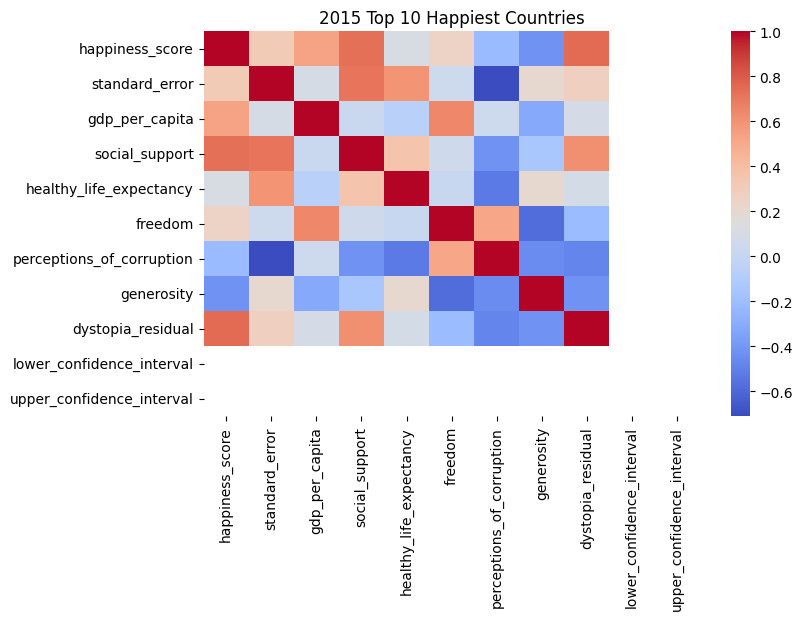

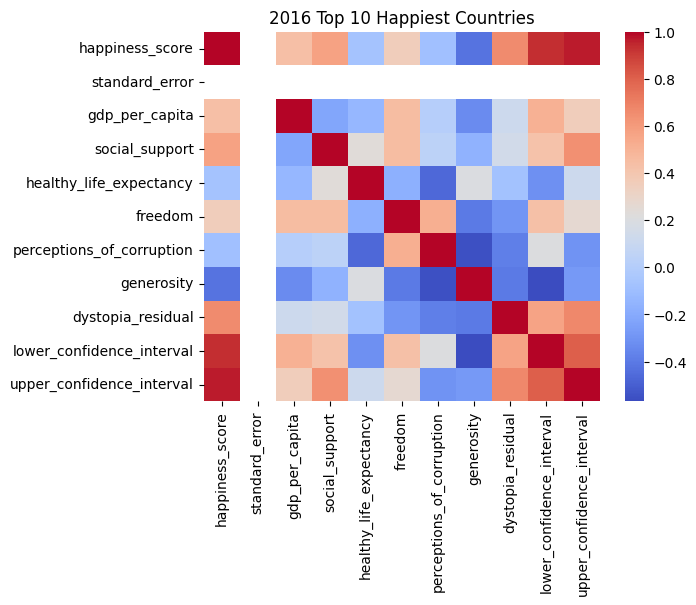

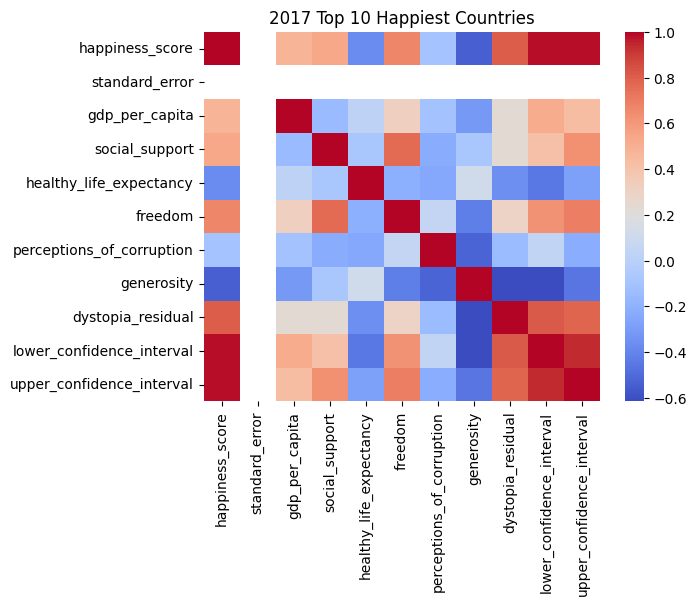

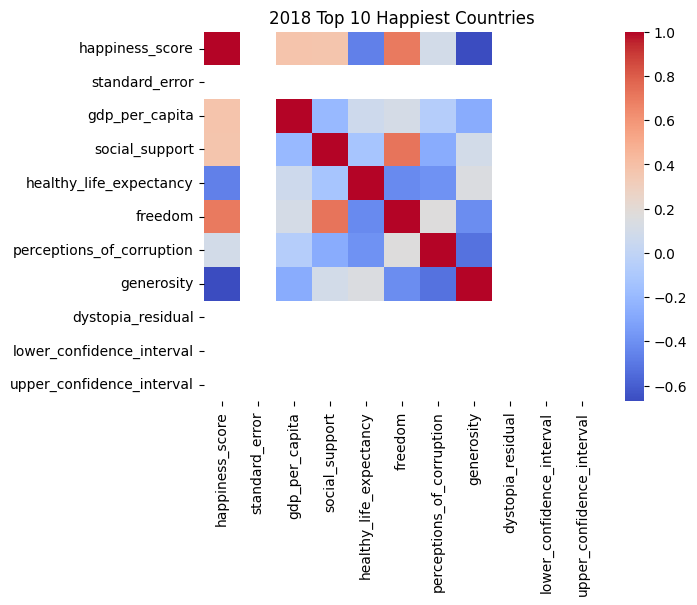

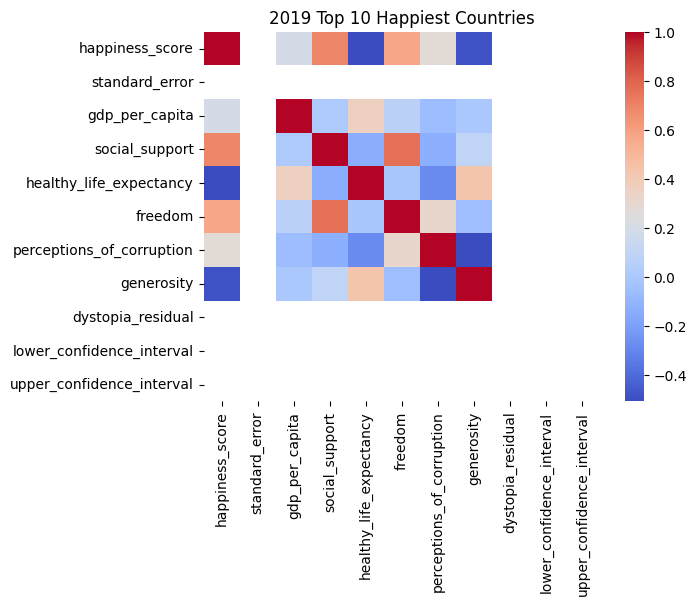

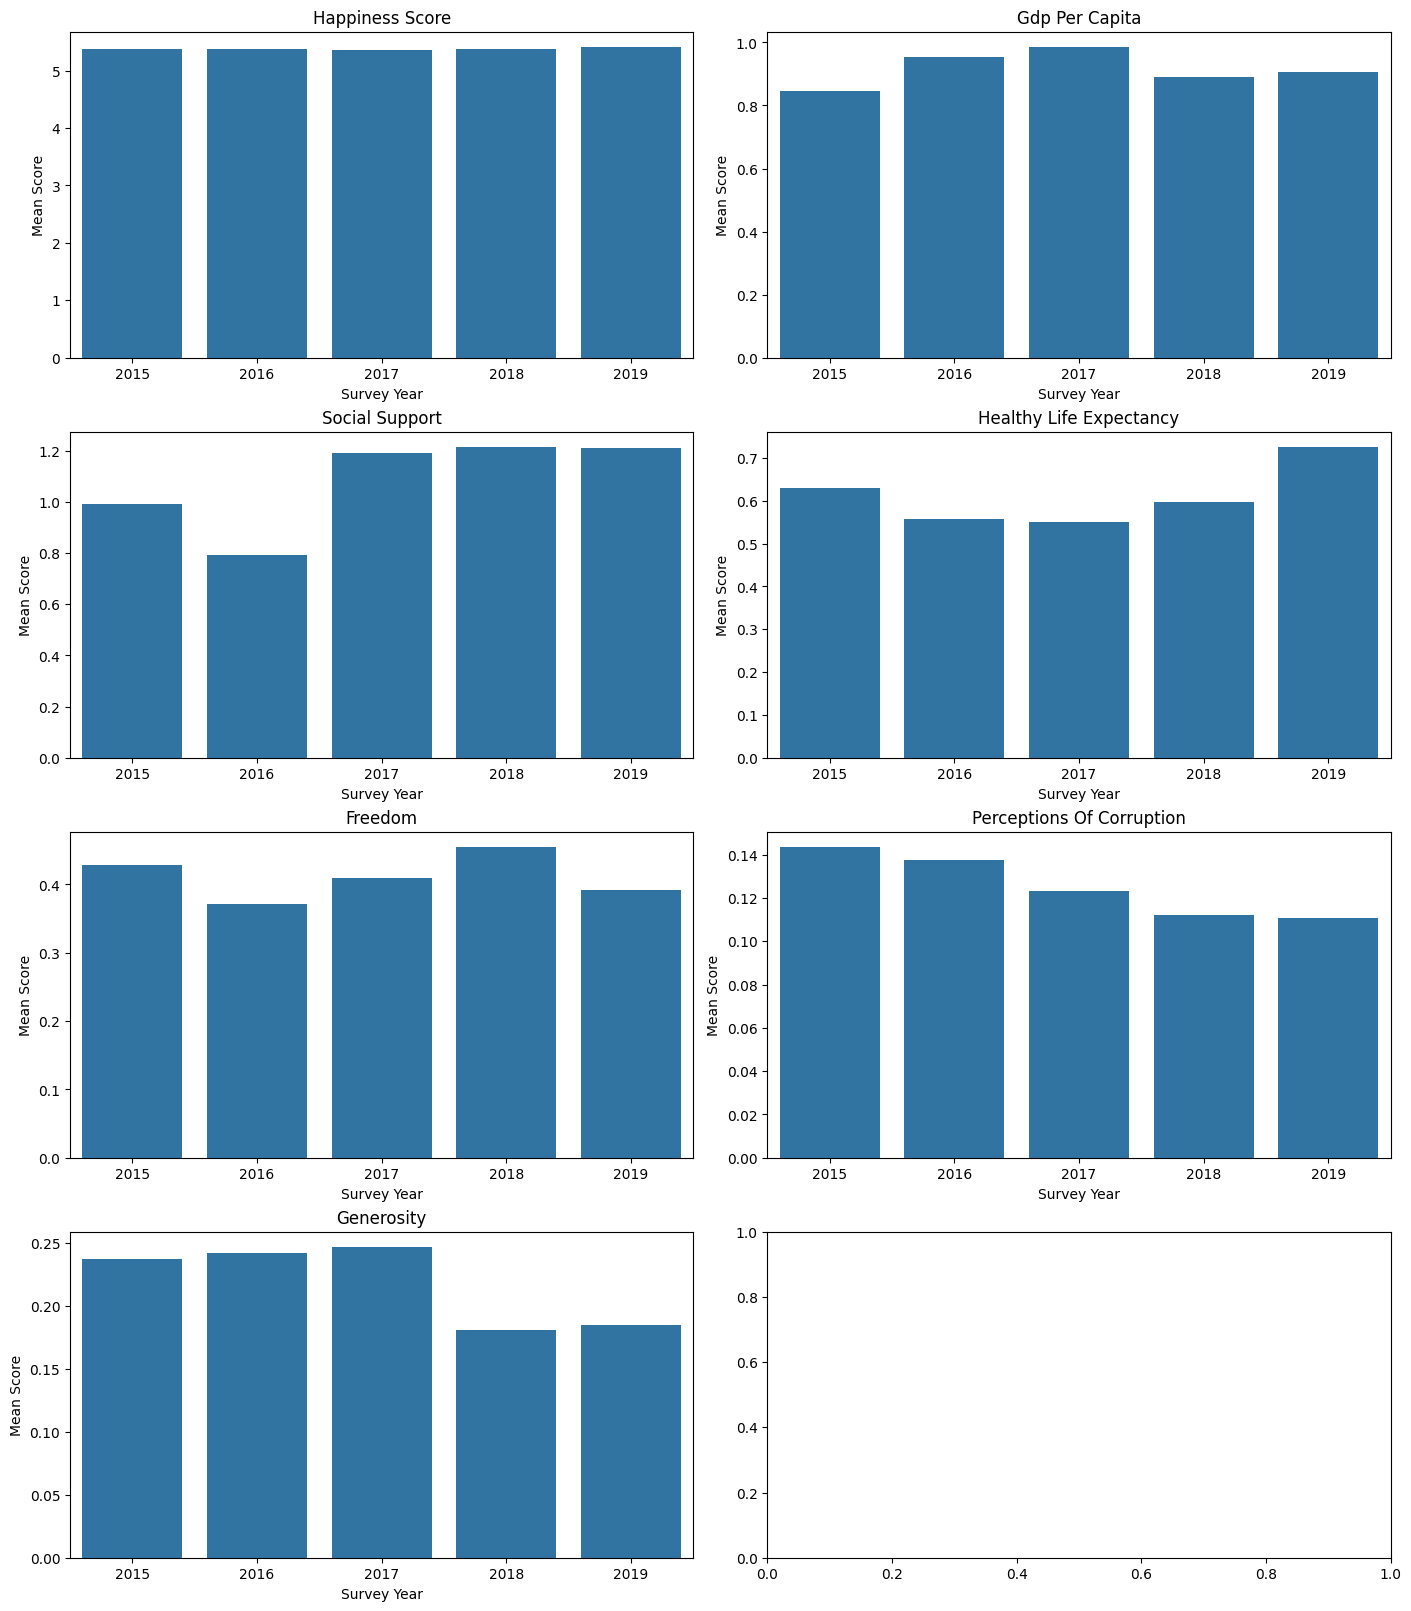

In [15]:
# Look at the top 10 happiest countries each year
top10_2015 = df[(df['survey_year'] == 2015) & (df['happiness_rank'] < 11)]

top10_2016 = df[(df['survey_year'] == 2016) & (df['happiness_rank'] < 11)]

top10_2017 = df[(df['survey_year'] == 2017) & (df['happiness_rank'] < 11)]

top10_2018 = df[(df['survey_year'] == 2018) & (df['happiness_rank'] < 11)]

top10_2019 = df[(df['survey_year'] == 2019) & (df['happiness_rank'] < 11)]

# Yearly pairplot/heat map of features
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))


sns.heatmap(top10_2015.select_dtypes(include='float64').corr(), cmap="coolwarm", annot=False)
plt.title("2015 Top 10 Happiest Countries")
plt.show()

sns.heatmap(top10_2016.select_dtypes(include='float64').corr(), cmap="coolwarm", annot=False)
plt.title("2016 Top 10 Happiest Countries")
plt.show()

sns.heatmap(top10_2017.select_dtypes(include='float64').corr(), cmap="coolwarm", annot=False)
plt.title("2017 Top 10 Happiest Countries")
plt.show()

sns.heatmap(top10_2018.select_dtypes(include='float64').corr(), cmap="coolwarm", annot=False)
plt.title("2018 Top 10 Happiest Countries")
plt.show()

sns.heatmap(top10_2019.select_dtypes(include='float64').corr(), cmap="coolwarm", annot=False)
plt.title("2019 Top 10 Happiest Countries")
plt.show()


# Vizualize how the mean scores changed year over year
metrics = [
    "happiness_score",
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom",
    "perceptions_of_corruption",
    "generosity",
]

yearly_metric_means = (
    df.groupby("survey_year")[metrics]
    .mean()
    .reset_index()
)

ncols = 2
nrows = 4 

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 4 * nrows),
    constrained_layout=True,
)

axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=yearly_metric_means,
        x="survey_year",
        y=metric,
        legend=False,
        ax=ax,
    )

    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("Survey Year")
    ax.set_ylabel("Mean Score")



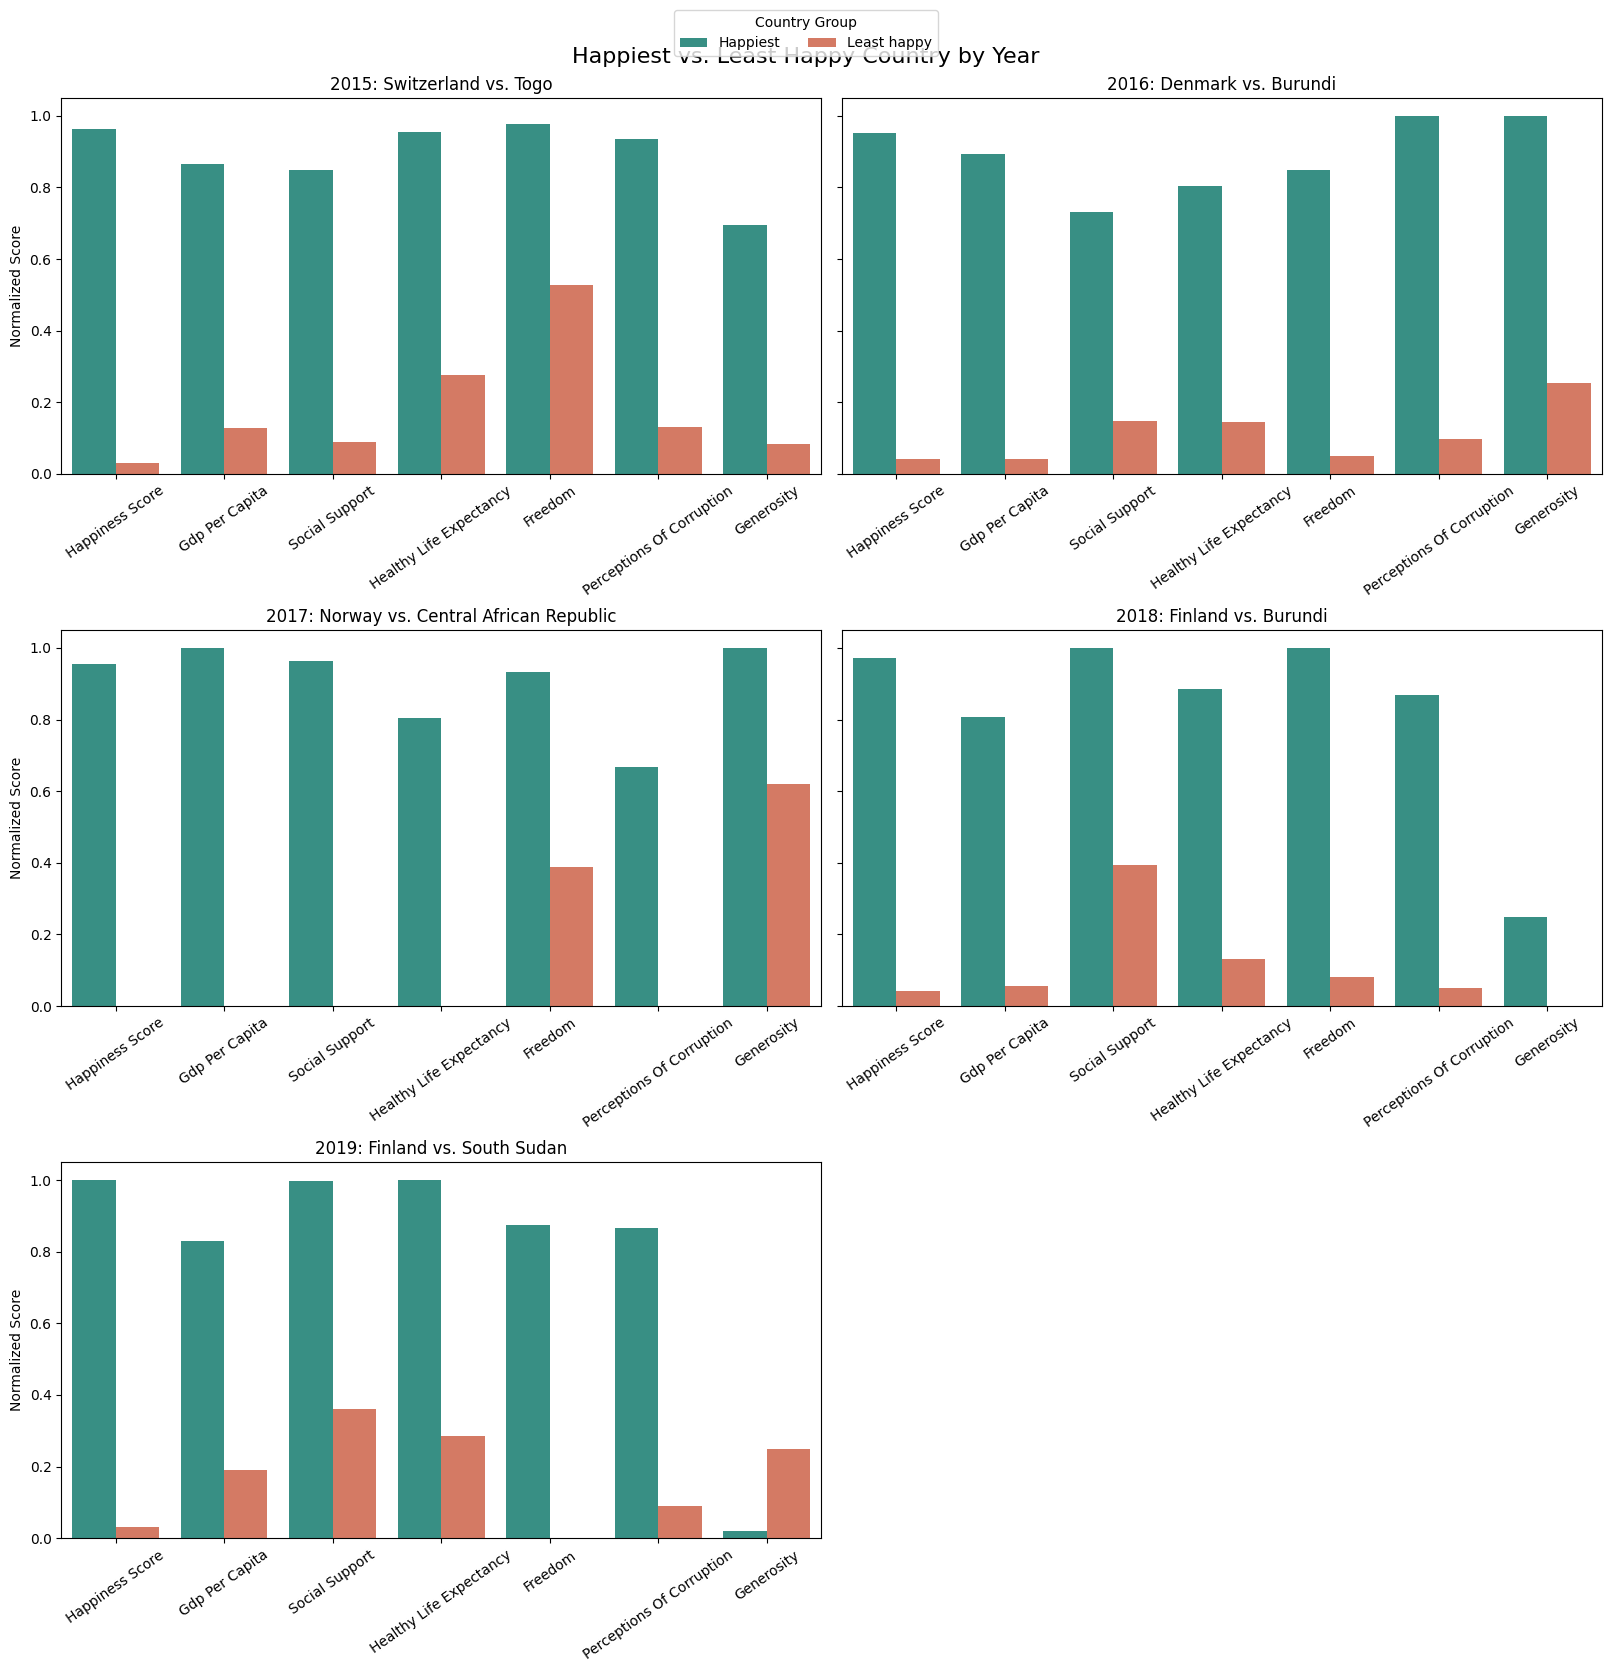

In [7]:
# applying normalization across entire dataset
normalized_ex_countries = min_max_normalization(df, metrics, extreme_countries)
normalized_ex_countries

# Understand trends comparing the happiest country with the unhappiest country each year
happiest_idx = (
    normalized_ex_countries.groupby("survey_year")["happiness_score"]
    .idxmax()
)

least_happy_idx = (
    normalized_ex_countries.groupby("survey_year")["happiness_score"]
    .idxmin()
)

happiest = normalized_ex_countries.loc[happiest_idx].copy()
happiest["category"] = "Happiest"

least_happy = normalized_ex_countries.loc[least_happy_idx].copy()
least_happy["category"] = "Least happy"

extreme_countries = pd.concat(
    [happiest, least_happy],
    ignore_index=True,
)

plot_df = extreme_countries.melt(
    id_vars=[
        "survey_year",
        "country",
        "category",
    ],
    value_vars=metrics,
    var_name="metric",
    value_name="normalized_score",
)

plot_df["metric"] = (
    plot_df["metric"]
    .str.replace("_", " ")
    .str.title()
)

years = sorted(normalized_ex_countries["survey_year"].unique())

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 5 * nrows),
    sharey=True,
    constrained_layout=True,
)

axes = axes.flatten()

for ax, year in zip(axes, years):
    year_df = plot_df[
        plot_df["survey_year"] == year
    ]

    sns.barplot(
        data=year_df,
        x="metric",
        y="normalized_score",
        hue="category",
        palette={
            "Happiest": "#2a9d8f",
            "Least happy": "#e76f51",
        },
        errorbar=None,
        ax=ax,
    )

    names = (
        year_df[["category", "country"]]
        .drop_duplicates()
        .set_index("category")["country"]
    )

    ax.set_title(
        f"{year}: {names['Happiest']} vs. "
        f"{names['Least happy']}"
    )
    ax.set_xlabel("")
    ax.set_ylabel("Normalized Score")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=35)

# Use one shared legend
handles, labels = axes[0].get_legend_handles_labels()

for ax in axes:
    legend = ax.get_legend()
    if legend:
        legend.remove()

for ax in axes[len(years):]:
    fig.delaxes(ax)

fig.legend(
    handles,
    labels,
    title="Country Group",
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "Happiest vs. Least Happy Country by Year",
    fontsize=16,
)

plt.show()


In [11]:
# Feature Engineering
# Because I have concatenated annual survey results, I think it makes sense to create a lagged feature for the happiness score 
import numpy as np

panel_df = df.copy()

panel_df = panel_df.sort_values(
    ["country", "survey_year"]
).reset_index(drop=True)

panel_df["previous_survey_year"] = (
    panel_df.groupby("country")["survey_year"]
    .shift(1)
)

consecutive_year = (
    panel_df["survey_year"]
    - panel_df["previous_survey_year"]
).eq(1)

for metric in metrics:
    lag_column = f"{metric}_lag1"
    change_column = f"{metric}_yoy_change"
    pct_change_column = f"{metric}_yoy_pct_change"

    # Previous year's value
    panel_df[lag_column] = (
        panel_df.groupby("country")[metric]
        .shift(1)
    )

    # Current value minus previous-year value
    panel_df[change_column] = (
        panel_df[metric] - panel_df[lag_column]
    )

    # Percentage change from previous year
    previous_nonzero = (
        panel_df[lag_column].replace(0, np.nan)
    )

    panel_df[pct_change_column] = (
        panel_df[change_column]
        / previous_nonzero
        * 100
    )

    # Remove changes when the preceding observation is not one year earlier
    generated_columns = [
        lag_column,
        change_column,
        pct_change_column,
    ]

    panel_df.loc[
        ~consecutive_year,
        generated_columns,
    ] = np.nan

panel_df

,country,region,happiness_rank,happiness_score,standard_error,gdp_per_capita,social_support,healthy_life_expectancy,freedom,perceptions_of_corruption,...,healthy_life_expectancy_yoy_pct_change,freedom_lag1,freedom_yoy_change,freedom_yoy_pct_change,perceptions_of_corruption_lag1,perceptions_of_corruption_yoy_change,perceptions_of_corruption_yoy_pct_change,generosity_lag1,generosity_yoy_change,generosity_yoy_pct_change
0,Afghanistan,Southern Asia,153,3.575,0.03084,0.319820,0.302850,0.303350,0.234140,0.097190,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,Southern Asia,154,3.360,NaN,0.382270,0.110370,0.173440,0.164300,0.071120,...,-42.825119,0.234140,-0.069840,-29.828308,0.097190,-0.026070,-26.823747,0.365100,-0.052420,-14.357710
2,Afghanistan,NaN,141,3.794,NaN,0.401477,0.581543,0.180747,0.106180,0.061158,...,4.212857,0.164300,-0.058120,-35.374607,0.071120,-0.009962,-14.007551,0.312680,-0.000809,-0.258753
3,Afghanistan,NaN,145,3.632,NaN,0.332000,0.537000,0.255000,0.085000,0.036000,...,41.081352,0.106180,-0.021180,-19.946898,0.061158,-0.025158,-41.135910,0.311871,-0.120871,-38.756716
4,Afghanistan,NaN,154,3.203,NaN,0.350000,0.517000,0.361000,0.000000,0.025000,...,41.568627,0.085000,-0.085000,-100.000000,0.036000,-0.011000,-30.555556,0.191000,-0.033000,-17.277487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,Zimbabwe,Sub-Saharan Africa,115,4.610,0.04290,0.271000,1.032760,0.334750,0.258610,0.080790,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
778,Zimbabwe,Sub-Saharan Africa,131,4.193,NaN,0.350410,0.714780,0.159500,0.254290,0.085820,...,-52.352502,0.258610,-0.004320,-1.670469,0.080790,0.005030,6.226018,0.189870,-0.004840,-2.549113
779,Zimbabwe,NaN,138,3.875,NaN,0.375847,1.083096,0.196764,0.336384,0.095375,...,23.362855,0.254290,0.082094,32.283695,0.085820,0.009555,11.134213,0.185030,0.004113,2.223150
780,Zimbabwe,NaN,144,3.692,NaN,0.357000,1.094000,0.248000,0.406000,0.099000,...,26.039474,0.336384,0.069616,20.695321,0.095375,0.003625,3.800371,0.189143,-0.057143,-30.211715


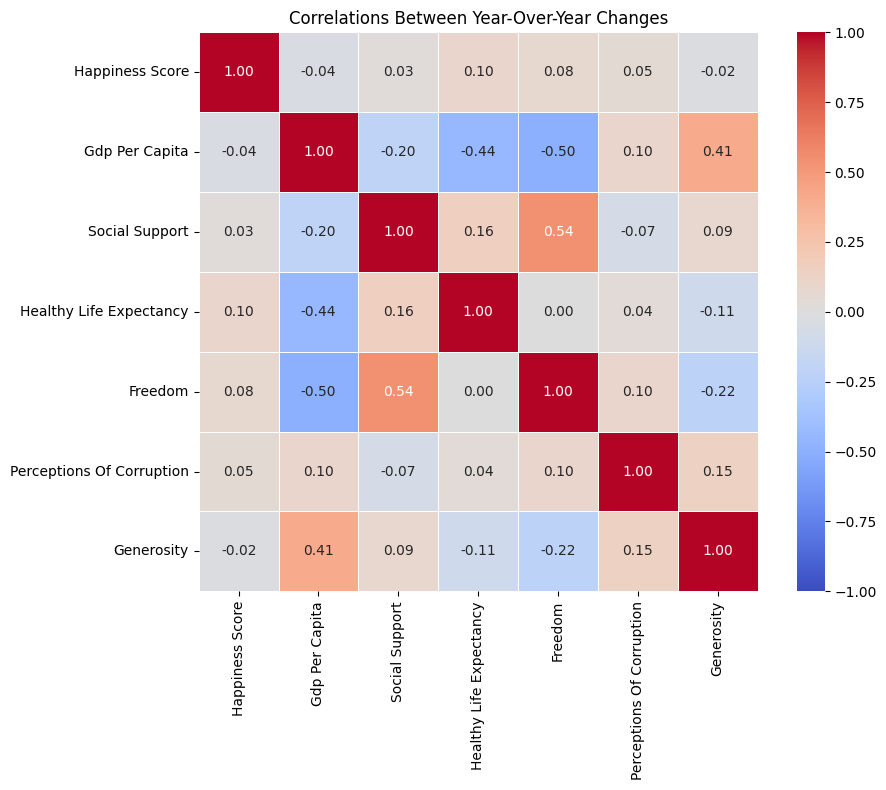

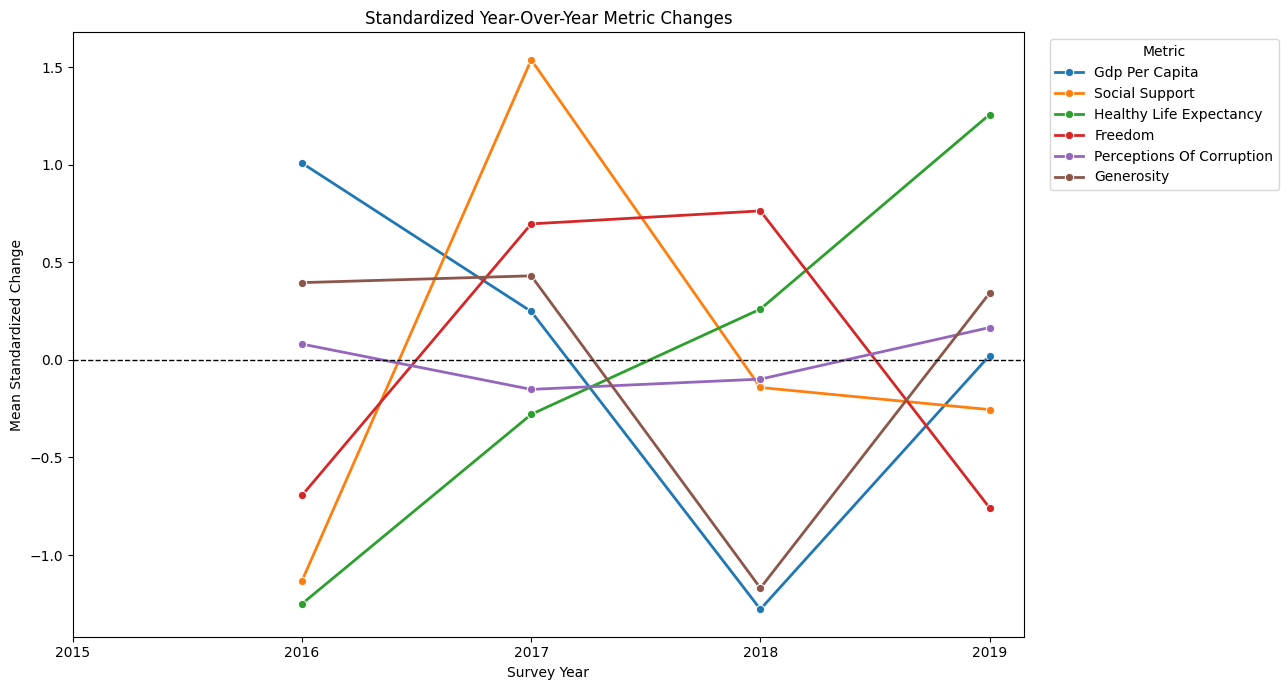

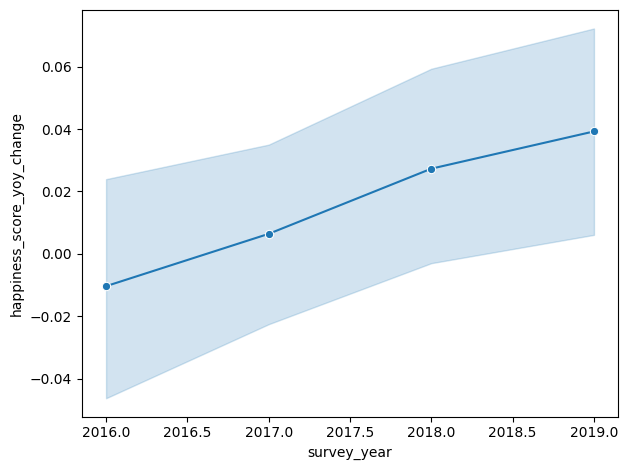

In [ ]:
# Vizualize with engineered lag features
change_features = [
    "gdp_per_capita_yoy_change",
    "social_support_yoy_change",
    "healthy_life_expectancy_yoy_change",
    "freedom_yoy_change",
    "perceptions_of_corruption_yoy_change",
    "generosity_yoy_change",
]

change_columns = [
    "happiness_score_yoy_change",
    *change_features,
]

change_corr = (
    panel_df[change_columns]
    .corr()
)

labels = {
    column: (
        column
        .replace("_yoy_change", "")
        .replace("_", " ")
        .title()
    )
    for column in change_columns
}

change_corr = change_corr.rename(
    index=labels,
    columns=labels,
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    change_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
)

plt.title("Correlations Between Year-Over-Year Changes")
plt.tight_layout()
plt.show()

# View changes year over year across all metrics 
change_long_df = panel_df.melt(
    id_vars=[
        "country",
        "survey_year",
    ],
    value_vars=change_features,
    var_name="metric",
    value_name="yearly_change",
).dropna(subset=["yearly_change"])

change_long_df["metric"] = (
    change_long_df["metric"]
    .str.replace("_yoy_change", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
)

standardized_changes = panel_df[
    ["country", "survey_year", *change_features]
].copy()

means = standardized_changes[change_features].mean()
standard_deviations = (
    standardized_changes[change_features]
    .std()
    .replace(0, 1)
)

standardized_changes[change_features] = (
    standardized_changes[change_features] - means
) / standard_deviations
yearly_standardized_changes = (
    standardized_changes
    .groupby("survey_year", as_index=False)[change_features]
    .mean()
)

overlay_df = yearly_standardized_changes.melt(
    id_vars="survey_year",
    value_vars=change_features,
    var_name="metric",
    value_name="standardized_change",
)

overlay_df["metric"] = (
    overlay_df["metric"]
    .str.replace("_yoy_change", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
)

plt.figure(figsize=(13, 7))

sns.lineplot(
    data=overlay_df,
    x="survey_year",
    y="standardized_change",
    hue="metric",
    marker="o",
    linewidth=2,
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

plt.xticks(years)
plt.title("Standardized Year-Over-Year Metric Changes")
plt.xlabel("Survey Year")
plt.ylabel("Mean Standardized Change")
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

sns.lineplot(
    data=panel_df,
    x="survey_year",
    y="happiness_score_yoy_change",
    marker="o",
)

plt.tight_layout()
plt.show()